This notebook is an order-of-magnitude physics screen for the question:

> What would it take to move a mechanically coherent crustal/lithospheric shell by 104°?

It deliberately separates four things:

1. **Kinematic requirement** - how far and how fast?
2. **Kinetic-energy requirement** — how much kinetic energy does the moving shell carry?
3. **Angular impulse requirement** — how much angular momentum must be transferred into the shell?
4. **Mean torque requirement** — what sustained torque scale is implied?


This is not a proof for or against any historical event. It is a first-pass constraint screen.

## Modeling assumptions

Starting assumptions:

- Earth is treated as a sphere with radius `R = 6371 km`.
- The angular displacement is `104°`, or about `1.815 rad`.
- The surface path length is estimated as `s = Rθ`, representing a maximum/equatorial-scale displacement path.
- The moving shell is treated as moving relative to the rest of Earth.
- The kinetic-energy calculation estimates the kinetic energy of the relative shell motion. It does **not** include the full thermodynamic or mechanical work required to fracture, heat, decouple, shear, or deform the lithosphere.
- The whole-Earth case is included only as an upper-bound reference, not as the preferred physical model.

This notebook includes two types of moving-shell estimates:

1. **Simple spherical-shell baselines**  
   These use uniform-density spherical shells with prescribed thicknesses, used for order-of-magnitude comparison and sensitivity testing.

2. **LITHO1.0 grid-based shell estimates**  
   These use the gridded LITHO1-derived layer structure from the previous inertia-axis work, including layer thickness, radius, and density. These are the preferred estimates for the crust and lithosphere cases because they use the actual layer geometry rather than an idealized global shell.

| Case | Source | Density / inertia assumption |
|---|---|---|
| simple crust shell | uniform shell, 20 km thick | ρ = 2850 kg/m³ |
| simple lithosphere shell | uniform shell, 100 km thick | ρ = 3300 kg/m³ |
| simple 200 km shell | uniform shell, 200 km thick | ρ = 3300 kg/m³, sensitivity test |
| whole Earth upper bound | whole-Earth inertia | I = 0.3308MR² |
| LITHO1 solid crust | LITHO1 grid | sediments + crustal layers only |
| LITHO1 solid lithosphere | LITHO1 grid | sediments + crustal layers + lithospheric lid |
| LITHO1 lithosphere + surface loads | LITHO1 grid | solid lithosphere + water + ice |

For the LITHO1 grid-based cases, the dynamics calculation uses the **absolute density and layer geometry** columns, including `rho`, `radius_km`, and `dr_km`. It does not use `density_anomaly` or mass-anomaly columns, because this notebook asks how much total mass would have to move.

The grid-derived moment of inertia is an axis-averaged spherical estimate, not a full inertia-tensor calculation. That is appropriate for this first-pass energy/torque screen, but a later refinement should compute axis-specific moments of inertia for the actual proposed rotation axis.

For LITHO1 grid cases, the basal-shear conversion uses a solid-angle weighted representative basal radius for the variable-thickness moving shell. This affects only the approximate basal-shear values, not the shell mass, moment of inertia, kinetic-energy, or angular-impulse calculations.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# LITHO1.0 mass model
from pathlib import Path
import zipfile

# Expected data file.
DATA_CANDIDATES = [
    Path("LITHO1_lithosphere_density_anomaly_grid_with_water_ice.csv.zip"),
    Path("data/LITHO1_lithosphere_density_anomaly_grid_with_water_ice.csv.zip"),
    Path("LITHO1_lithosphere_density_anomaly_grid_with_water_ice.csv"),
    Path("data/LITHO1_lithosphere_density_anomaly_grid_with_water_ice.csv"),
]

litho_path = next((p for p in DATA_CANDIDATES if p.exists()), None)

if litho_path is None:
    raise FileNotFoundError(
        "Could not find the LITHO1 grid file. Expected one of:\n"
        + "\n".join(str(p) for p in DATA_CANDIDATES)
    )

if litho_path.suffix == ".zip":
    with zipfile.ZipFile(litho_path, "r") as z:
        csv_files = [
            name for name in z.namelist()
            if name.endswith(".csv") and not name.startswith("__MACOSX/")
        ]
        if len(csv_files) != 1:
            raise ValueError(f"Expected exactly one CSV in zip, found: {csv_files}")
        with z.open(csv_files[0]) as f:
            litho_df = pd.read_csv(f)
else:
    litho_df = pd.read_csv(litho_path)

print(f"Loaded LITHO1 grid from: {litho_path}")
display(litho_df.head(10))

Loaded LITHO1 grid from: LITHO1_lithosphere_density_anomaly_grid_with_water_ice.csv.zip


,lat,lon,layer,top_km,bottom_km,radius_km,dr_km,rho,rho_mean_layer,layer_mass_proxy,layer_mass_proxy_mean,layer_mass_anomaly,density_anomaly
0,89.5,-179.5,CRUST1,4.829,6.036,6365.5675,1.207,2450.95,2572.439323,2958.29665,15297.616415,-12339.319765,-10223.131537
1,89.5,-179.5,CRUST2,6.036,8.627,6363.6685,2.591,2792.73,2786.933386,7235.96343,18293.392420,-11057.428990,-4267.629869
2,89.5,-179.5,CRUST3,8.627,17.039,6358.1670,8.412,2967.15,2964.870489,24959.66580,26868.990436,-1909.324636,-226.976300
3,89.5,-179.5,LID,17.039,95.067,6314.9470,78.028,3300.00,3300.000000,257492.40000,270700.329416,-13207.929416,-169.271664
4,89.5,-179.5,SEDS1,3.368,4.667,6366.9825,1.299,1930.00,1946.362685,2507.07000,1121.611119,1385.458881,1066.558030
5,89.5,-179.5,SEDS2,4.667,4.829,6366.2520,0.162,2310.00,2345.210982,374.22000,3280.999779,-2906.779779,-17943.085058
6,89.5,-179.5,WATER,0.000,3.368,6369.3160,3.368,1020.00,1020.000000,3435.36000,3645.872551,-210.512551,-62.503727
7,89.5,-178.5,CRUST1,4.836,6.043,6365.5605,1.207,2451.04,2572.439323,2958.40528,15297.616415,-12339.211135,-10223.041537
8,89.5,-178.5,CRUST2,6.043,8.632,6363.6625,2.589,2792.33,2786.933386,7229.34237,18293.392420,-11064.050050,-4273.483990
9,89.5,-178.5,CRUST3,8.632,17.036,6358.1660,8.404,2966.92,2964.870489,24933.99568,26868.990436,-1934.994756,-230.246877


In [3]:
# clean + add SI-unit columns
litho_df = litho_df.copy()

# standardize layer names just in case
litho_df["layer"] = litho_df["layer"].astype(str).str.strip().str.upper()

# add SI-unit geometry columns
litho_df["top_m"] = litho_df["top_km"] * 1_000.0
litho_df["bottom_m"] = litho_df["bottom_km"] * 1_000.0
litho_df["radius_m"] = litho_df["radius_km"] * 1_000.0
litho_df["dr_m"] = litho_df["dr_km"] * 1_000.0

# make sure density is numeric
litho_df["rho"] = pd.to_numeric(litho_df["rho"], errors="coerce")

# quick QC
print("Rows:", len(litho_df))
print("Layers:", sorted(litho_df["layer"].unique()))
print("Lat range:", litho_df["lat"].min(), litho_df["lat"].max())
print("Lon range:", litho_df["lon"].min(), litho_df["lon"].max())
print("rho range:", litho_df["rho"].min(), litho_df["rho"].max())
print("dr_km range:", litho_df["dr_km"].min(), litho_df["dr_km"].max())

display(
    litho_df.groupby("layer")
    .agg(
        n=("rho", "size"),
        mean_rho=("rho", "mean"),
        min_top_km=("top_km", "min"),
        max_bottom_km=("bottom_km", "max"),
        mean_dr_km=("dr_km", "mean"),
        max_dr_km=("dr_km", "max"),
    )
    .sort_index()
)

Rows: 398822
Layers: ['CRUST1', 'CRUST2', 'CRUST3', 'ICE', 'LID', 'SEDS1', 'SEDS2', 'SEDS3', 'WATER']
Lat range: -89.5 89.5
Lon range: -179.5 179.5
rho range: 920.0 4602.0
dr_km range: 0.0009999999999994 1386.51


,n,mean_rho,min_top_km,max_bottom_km,mean_dr_km,max_dr_km
layer,,,,,,
CRUST1,64771,2594.760288,-9.127,28.228,6.386167,28.335
CRUST2,64770,2793.330070,-1.589,50.246,7.156530,33.186
CRUST3,64772,2968.773245,2.647,75.775,9.370968,36.337
ICE,7942,920.000000,-4.042,3.941,1.799787,3.966
LID,64773,3300.000000,-6.469,1435.882,89.457680,1386.510
SEDS1,63397,1972.703128,-6.294,26.578,0.658826,6.295
SEDS2,19791,2342.172928,-4.239,10.398,1.412804,4.231
SEDS3,4212,2545.806840,-3.214,20.329,1.298341,15.368
WATER,44394,1020.000000,-3.568,24.367,3.312642,24.367


In [4]:
# LITHO1.0 QC: inspect unusually deep lid cells
# These outliers matter mostly for approximate basal-interface/shear calculations,
# not for the kinetic-energy calculation if they occupy very few cells.

lid_df = litho_df[litho_df["layer"] == "LID"].copy()

lid_qc = pd.DataFrame({
    "bottom_km_quantile": lid_df["bottom_km"].quantile([0.50, 0.90, 0.95, 0.99, 0.999, 1.00])
})

n_lid = len(lid_df)
n_lid_gt_300 = int((lid_df["bottom_km"] > 300).sum())

print(f"LID cells deeper than 300 km: {n_lid_gt_300} of {n_lid} ({100*n_lid_gt_300/n_lid:.3f}%)")
display(lid_qc)


LID cells deeper than 300 km: 124 of 64773 (0.191%)


,bottom_km_quantile
0.500,88.43100
0.900,240.78840
0.950,256.23780
0.990,284.66168
0.999,303.25298
1.000,1435.88200


In [5]:
# constants

R_EARTH = 6_371_000.0                     # m, volumetric mean Earth radius
M_EARTH = 5.97217e24                      # kg
MOI_FACTOR_EARTH = 0.3308                 # I / (M R^2), whole-Earth upper-bound value
SIDEREAL_DAY = 23.9345 * 3600.0           # s
OMEGA_EARTH = 2 * math.pi / SIDEREAL_DAY  # rad/s

THETA_DEG = 104.0
THETA_RAD = math.radians(THETA_DEG)
SURFACE_PATH_M = R_EARTH * THETA_RAD

I_EARTH = MOI_FACTOR_EARTH * M_EARTH * R_EARTH**2
E_ROT_EARTH = 0.5 * I_EARTH * OMEGA_EARTH**2
L_ROT_EARTH = I_EARTH * OMEGA_EARTH

# solar power intercepted by Earth:
# P = TSI * projected disk area
TSI_NOMINAL = 1361.0                      # W/m^2, IAU nominal total solar irradiance
P_SOLAR_INTERCEPTED = TSI_NOMINAL * math.pi * R_EARTH**2

# Hypothetical solar micronova / solar outburst energy screen
AU_M = 1.495978707e11  # m

# Fraction of an isotropic solar outburst intercepted by Earth's cross-sectional disk:
# f = pi R_earth^2 / (4 pi AU^2) = R_earth^2 / (4 AU^2)
EARTH_INTERCEPT_FRACTION_ISOTROPIC = R_EARTH**2 / (4 * AU_M**2)


# earthquake energy screen:
# USGS gives approximate energy relation log10(E) = 5.24 + 1.44 Mw, E in joules.
MW_LARGEST = 9.5
E_LARGEST_EQ_APPROX = 10 ** (5.24 + 1.44 * MW_LARGEST)

# chicxulub range from one impactor assessment paper; keep as a broad range.
E_CHICXULUB_LOW = 1.3e24
E_CHICXULUB_HIGH = 5.8e25

# torque reference anchors
TORQUE_EM_CORE_MANTLE_EST = 5e19          # N m, approximate EM core-mantle coupling estimate
TIDAL_DISSIPATION_POWER = 3e12            # W, present-day tidal dissipation order
LUNAR_ORBIT_PERIOD = 27.321661 * 86400.0  # s
OMEGA_MOON = 2 * math.pi / LUNAR_ORBIT_PERIOD
TORQUE_TIDAL_PRESENT = TIDAL_DISSIPATION_POWER / (OMEGA_EARTH - OMEGA_MOON)

#layer groups from LITHO1.0 derived grid
CRUST_SOLID_LAYERS = [
    "SEDS1", "SEDS2", "SEDS3",
    "CRUST1", "CRUST2", "CRUST3",
]

LITHO_SOLID_LAYERS = [
    "SEDS1", "SEDS2", "SEDS3",
    "CRUST1", "CRUST2", "CRUST3",
    "LID",
]

SURFACE_LOAD_LAYERS = [
    "WATER", "ICE",
]

LITHO_PLUS_WATER_ICE_LAYERS = LITHO_SOLID_LAYERS + SURFACE_LOAD_LAYERS


print(f"Earth isotropic intercept fraction = {EARTH_INTERCEPT_FRACTION_ISOTROPIC:.3e}")

print(f"theta = {THETA_RAD:.4f} rad")
print(f"surface path = {SURFACE_PATH_M/1000:,.0f} km")
print(f"Earth rotational KE = {E_ROT_EARTH:.3e} J")
print(f"Earth rotational angular momentum = {L_ROT_EARTH:.3e} kg m^2/s")
print(f"Solar power intercepted = {P_SOLAR_INTERCEPTED:.3e} W")
print(f"Present tidal torque estimate from 3 TW dissipation = {TORQUE_TIDAL_PRESENT:.3e} N m")

Earth isotropic intercept fraction = 4.534e-10
theta = 1.8151 rad
surface path = 11,564 km
Earth rotational KE = 2.132e+29 J
Earth rotational angular momentum = 5.847e+33 kg m^2/s
Solar power intercepted = 1.735e+17 W
Present tidal torque estimate from 3 TW dissipation = 4.270e+16 N m


In [6]:
# helpers
def spherical_shell_mass_moi(
    outer_radius_m: float,
    inner_radius_m: float,
    density_kg_m3: float
) -> tuple[float, float]:
    """
    Uniform spherical shell mass and moment of inertia about a diameter.

    M = 4/3 pi rho (r_o^3 - r_i^3)
    I = 8/15 pi rho (r_o^5 - r_i^5)

    For a very thin shell this approaches I = (2/3) M R^2.
    """
    ro = float(outer_radius_m)
    ri = float(inner_radius_m)
    rho = float(density_kg_m3)

    if not (ro > ri >= 0):
        raise ValueError("Require outer_radius > inner_radius >= 0.")
    if rho <= 0:
        raise ValueError("Density must be positive.")

    mass = (4.0 / 3.0) * math.pi * rho * (ro**3 - ri**3)
    moi = (8.0 / 15.0) * math.pi * rho * (ro**5 - ri**5)
    return mass, moi


def seconds_from_label(label: str) -> float:
    """Convenience parser for the event windows used here."""
    mapping = {
        "1 hour": 3600.0,
        "6 hours": 6 * 3600.0,
        "1 day": 86400.0,
        "1 week": 7 * 86400.0,
        "1 month": 30.4375 * 86400.0,
        "1 year": 365.25 * 86400.0,
        "1,000 years": 1000 * 365.25 * 86400.0,
    }
    return mapping[label]


def log10_safe(x: float) -> float:
    return np.nan if (x is None or not np.isfinite(x) or x <= 0) else math.log10(x)


def energy_scale_label(E: float) -> str:
    """
    Plain-English energy scale labels.
    These are intentionally coarse bins.
    """
    if E < E_LARGEST_EQ_APPROX:
        return "below largest-earthquake radiated-energy scale"
    if E < 1e21:
        return "great-earthquake / super-earthquake scale"
    if E < E_CHICXULUB_LOW:
        return "between earthquake and Chicxulub scale"
    if E <= E_CHICXULUB_HIGH:
        return "Chicxulub-range impact scale"
    if E < 0.01 * E_ROT_EARTH:
        return "above Chicxulub; below 1% Earth rotation KE"
    if E < E_ROT_EARTH:
        return "planetary rotation-energy scale"
    return "exceeds Earth rotational KE"


def torque_scale_label(torque: float) -> str:
    if torque < TORQUE_TIDAL_PRESENT:
        return "below present lunar tidal torque"
    if torque < TORQUE_EM_CORE_MANTLE_EST:
        return "above tidal, below EM core-mantle estimate"
    if torque < 1e24:
        return "above EM core-mantle estimate"
    if torque < 1e27:
        return "huge geophysical torque"
    return "extreme / global-coupling torque"


def basal_torque_from_uniform_shear(stress_pa: float, interface_radius_m: float) -> float:
    """
    Order-of-magnitude torque from uniform azimuthal basal shear on a spherical interface.

    For uniform tangential shear stress around an axis:
        Torque ~ pi^2 * stress * r^3

    The geometric prefactor is not the point; this is a global-scale screening estimate.
    """
    if interface_radius_m <= 0:
        return np.nan
    return math.pi**2 * stress_pa * interface_radius_m**3


def uniform_basal_shear_from_torque(torque_nm: float, interface_radius_m: float) -> float:
    """Invert basal_torque_from_uniform_shear."""
    if interface_radius_m <= 0:
        return np.nan
    return torque_nm / (math.pi**2 * interface_radius_m**3)


def force_couple_each_force(torque_nm: float, lever_arm_m: float = 2 * R_EARTH) -> float:
    """
    Equivalent force on each side of an idealized equal/opposite force couple.
    torque = F * lever_arm
    """
    return torque_nm / lever_arm_m


def frictional_sliding_work(stress_pa: float, interface_radius_m: float, angular_displacement_rad: float) -> float:
    """
    Work to slide a shell over a spherical basal interface under uniform shear stress.

    Work = stress * area * slip_distance
         ~ stress * 4 pi r^2 * (r * theta)
         = 4 pi stress r^3 theta

    This is separate from kinetic energy.
    """
    if interface_radius_m <= 0:
        return np.nan
    area = 4 * math.pi * interface_radius_m**2
    slip_distance = interface_radius_m * angular_displacement_rad
    return stress_pa * area * slip_distance


def viscous_shear_stress(velocity_m_s: float, viscosity_pa_s: float, shear_zone_thickness_m: float) -> float:
    """
    Newtonian viscous shear stress estimate:
        tau = eta * dv/dz
            ~ eta * velocity / shear_zone_thickness
    """
    return viscosity_pa_s * velocity_m_s / shear_zone_thickness_m

def infer_grid_spacing_deg(values):
    """
    Infer regular grid spacing from latitude or longitude center values.
    """
    unique_vals = np.sort(pd.Series(values).dropna().unique())
    diffs = np.diff(unique_vals)

    if len(diffs) == 0:
        raise ValueError("Could not infer grid spacing.")

    return float(np.median(diffs))


def litho_grid_mass_moi(
    df,
    layers,
    radius_col="radius_m",
    dr_col="dr_m",
    rho_col="rho",
    lat_col="lat",
):
    """
    Estimate total mass and moment of inertia from a gridded LITHO1-style layer table.

    Uses:
        dm = rho * dV

    with spherical cell volume:

        dV = dOmega * (r_outer^3 - r_inner^3) / 3

    and axis-averaged moment of inertia:

        I_avg = (2/3) * ∫ r^2 dm

    This gives a diameter-axis moment of inertia comparable to the simple
    spherical-shell formula used elsewhere in the notebook.

    Notes:
    - Uses actual gridded layer thicknesses and densities.
    - Uses absolute density rho, not density_anomaly.
    - Assumes lat/lon values are cell centers on a regular grid.
    """

    use = df[df["layer"].isin(layers)].copy()

    if use.empty:
        raise ValueError(f"No rows found for layers: {layers}")

    # infer grid spacing from cell centers
    dlat_deg = infer_grid_spacing_deg(use["lat"])
    dlon_deg = infer_grid_spacing_deg(use["lon"])

    # latitude cell edges
    lat_lower = np.clip(use[lat_col].to_numpy() - dlat_deg / 2, -90, 90)
    lat_upper = np.clip(use[lat_col].to_numpy() + dlat_deg / 2, -90, 90)

    lat_lower_rad = np.deg2rad(lat_lower)
    lat_upper_rad = np.deg2rad(lat_upper)
    dlon_rad = np.deg2rad(dlon_deg)

    # solid angle of each lat/lon cell
    dOmega = dlon_rad * (np.sin(lat_upper_rad) - np.sin(lat_lower_rad))

    # radial shell boundaries from midpoint radius and thickness
    r_mid = use[radius_col].to_numpy()
    dr = use[dr_col].to_numpy()

    r_outer = r_mid + dr / 2
    r_inner = r_mid - dr / 2

    rho = use[rho_col].to_numpy()

    # cell volume and mass
    dV = dOmega * (r_outer**3 - r_inner**3) / 3.0
    dm = rho * dV

    # axis-averaged diameter moment of inertia
    # I = (2/3) * ∫ r^2 dm
    dI = (2.0 / 3.0) * rho * dOmega * (r_outer**5 - r_inner**5) / 5.0

    mass_kg = np.nansum(dm)
    moi_kg_m2 = np.nansum(dI)

    return mass_kg, moi_kg_m2

    

def effective_interface_radius_from_grid(
    df,
    layers,
    lat_col="lat",
    lon_col="lon",
    bottom_col="bottom_m",
):
    """
    Representative basal-interface radius for a variable-thickness gridded shell.

    For each lat/lon column, this uses the deepest bottom depth among the selected
    layers as the local base of the moving shell. It then returns a solid-angle
    weighted effective radius based on mean(r_base^3)^(1/3), which matches the
    r^3 scaling used in the basal-shear torque approximation.

    This is only used for approximate basal-shear conversion. The shell mass and
    moment of inertia are computed independently from the full layer grid.
    """
    use = df[df["layer"].isin(layers)].copy()
    if use.empty:
        raise ValueError(f"No rows found for layers: {layers}")

    base = (
        use.groupby([lat_col, lon_col], as_index=False)[bottom_col]
        .max()
        .rename(columns={bottom_col: "base_depth_m"})
    )

    dlat_deg = infer_grid_spacing_deg(base[lat_col])
    dlon_deg = infer_grid_spacing_deg(base[lon_col])

    lat_lower = np.clip(base[lat_col].to_numpy() - dlat_deg / 2, -90, 90)
    lat_upper = np.clip(base[lat_col].to_numpy() + dlat_deg / 2, -90, 90)

    weights = np.deg2rad(dlon_deg) * (
        np.sin(np.deg2rad(lat_upper)) - np.sin(np.deg2rad(lat_lower))
    )

    r_base = R_EARTH - base["base_depth_m"].to_numpy()
    r_eff = (np.nansum(weights * r_base**3) / np.nansum(weights)) ** (1 / 3)

    return float(r_eff)


In [7]:
# definition of shell cases and event windows

shell_cases = [
    # simple spherical-shell baselines
    {
        "moving_shell": "simple crust shell, 20 km",
        "case_type": "simple_shell",
        "thickness_m": 20e3,
        "density_kg_m3": 2850.0,
        "notes": "uniform-density baseline crust shell"
    },
    {
        "moving_shell": "simple lithosphere shell, 100 km",
        "case_type": "simple_shell",
        "thickness_m": 100e3,
        "density_kg_m3": 3300.0,
        "notes": "uniform-density baseline lithosphere shell"
    },
    {
        "moving_shell": "simple 200 km shell",
        "case_type": "simple_shell",
        "thickness_m": 200e3,
        "density_kg_m3": 3300.0,
        "notes": "uniform-density uppermost-mantle sensitivity test"
    },

    # LITHO1.0 grid-based cases
    {
        "moving_shell": "LITHO1 solid crust",
        "case_type": "litho_grid",
        "layers": CRUST_SOLID_LAYERS,
        "notes": "LITHO1 sediments + crustal layers; uses actual grid density and thickness"
    },
    {
        "moving_shell": "LITHO1 solid lithosphere",
        "case_type": "litho_grid",
        "layers": LITHO_SOLID_LAYERS,
        "notes": "LITHO1 sediments + crustal layers + lithospheric lid"
    },
    {
        "moving_shell": "LITHO1 lithosphere + water + ice",
        "case_type": "litho_grid",
        "layers": LITHO_PLUS_WATER_ICE_LAYERS,
        "notes": "LITHO1 solid lithosphere plus surface water and ice loads"
    },

    # whole-Earth upper bound
    {
        "moving_shell": "whole Earth upper bound",
        "case_type": "whole_earth",
        "thickness_m": R_EARTH,
        "density_kg_m3": np.nan,
        "notes": "uses I = 0.3308MR²; upper bound only"
    }
]


event_windows = {
    "1 hour": seconds_from_label("1 hour"),
    "6 hours": seconds_from_label("6 hours"),
    "1 day": seconds_from_label("1 day"),
    "1 week": seconds_from_label("1 week"),
    "1 month": seconds_from_label("1 month"),
    "1 year": seconds_from_label("1 year"),
    "1,000 years": seconds_from_label("1,000 years"),
}

In [8]:
# build shell summary table

shell_rows = []

for case in shell_cases:
    name = case["moving_shell"]
    case_type = case["case_type"]

    if case_type == "simple_shell":
        thickness = case["thickness_m"]
        outer_radius = R_EARTH
        inner_radius = R_EARTH - thickness

        mass, moi = spherical_shell_mass_moi(
            outer_radius_m=outer_radius,
            inner_radius_m=inner_radius,
            density_kg_m3=case["density_kg_m3"],
        )

        layers = None

    elif case_type == "litho_grid":
        mass, moi = litho_grid_mass_moi(
            df=litho_df,
            layers=case["layers"],
            radius_col="radius_m",
            dr_col="dr_m",
            rho_col="rho",
            lat_col="lat",
        )

        thickness = np.nan
        outer_radius = R_EARTH

        # Effective interface radius for basal shear approximations.
        # This is a solid-angle weighted representative radius for a variable-thickness shell.
        # It affects only basal-shear conversion, not the mass or kinetic-energy estimate.
        inner_radius = effective_interface_radius_from_grid(
            df=litho_df,
            layers=case["layers"],
            lat_col="lat",
            lon_col="lon",
            bottom_col="bottom_m",
        )
        layers = case["layers"]

    elif case_type == "whole_earth":
        thickness = R_EARTH
        mass = M_EARTH
        moi = I_EARTH
        outer_radius = R_EARTH
        inner_radius = 0.0
        layers = None

    else:
        raise ValueError(f"Unknown case_type: {case_type}")

    shell_rows.append({
        "moving_shell": name,
        "case_type": case_type,
        "layers": layers,
        "thickness_km": thickness / 1000 if np.isfinite(thickness) else np.nan,
        "density_kg_m3": case.get("density_kg_m3", np.nan),
        "mass_kg": mass,
        "moment_of_inertia_kg_m2": moi,
        "log10_mass": log10_safe(mass),
        "log10_I": log10_safe(moi),
        "inner_or_interface_radius_m": inner_radius,
        "notes": case["notes"],
    })

shell_df = pd.DataFrame(shell_rows)

display(shell_df)

,moving_shell,case_type,layers,thickness_km,density_kg_m3,mass_kg,moment_of_inertia_kg_m2,log10_mass,log10_I,inner_or_interface_radius_m,notes
0,"simple crust shell, 20 km",simple_shell,None,20.0,2850.0,2.898250e+22,7.818027e+35,22.462136,35.893097,6.351000e+06,uniform-density baseline crust shell
1,"simple lithosphere shell, 100 km",simple_shell,None,100.0,3300.0,1.656931e+23,4.413977e+36,23.219304,36.644830,6.271000e+06,uniform-density baseline lithosphere shell
2,simple 200 km shell,simple_shell,None,200.0,3300.0,3.261852e+23,8.555208e+36,23.513464,36.932231,6.171000e+06,uniform-density uppermost-mantle sensitivity test
3,LITHO1 solid crust,litho_grid,"[SEDS1, SEDS2, SEDS3, CRUST1, CRUST2, CRUST3]",NaN,NaN,3.174707e+22,8.542047e+35,22.501704,35.931562,6.346413e+06,LITHO1 sediments + crustal layers; uses actual...
4,LITHO1 solid lithosphere,litho_grid,"[SEDS1, SEDS2, SEDS3, CRUST1, CRUST2, CRUST3, ...",NaN,NaN,1.657845e+23,4.378653e+36,23.219544,36.641340,6.265092e+06,LITHO1 sediments + crustal layers + lithospher...
5,LITHO1 lithosphere + water + ice,litho_grid,"[SEDS1, SEDS2, SEDS3, CRUST1, CRUST2, CRUST3, ...",NaN,NaN,1.671711e+23,4.416150e+36,23.223161,36.645044,6.265097e+06,LITHO1 solid lithosphere plus surface water an...
6,whole Earth upper bound,whole_earth,None,6371.0,NaN,5.972170e+24,8.018864e+37,24.776132,37.904113,0.000000e+00,uses I = 0.3308MR²; upper bound only


In [9]:
# test 1: kinematic + kinetic-energy requirement
rows = []

for _, shell in shell_df.iterrows():
    I = shell["moment_of_inertia_kg_m2"]
    interface_radius = shell["inner_or_interface_radius_m"]

    for label, T in event_windows.items():
        omega_mean = THETA_RAD / T
        omega_peak_triangular = 2 * THETA_RAD / T
        v_surface = SURFACE_PATH_M / T

        # Kinetic energy screens
        ke_mean = 0.5 * I * omega_mean**2
        ke_peak_triangular = 0.5 * I * omega_peak_triangular**2
        work_throughput_start_stop = 2 * ke_peak_triangular

        rows.append({
            "moving_shell": shell["moving_shell"],
            "timescale": label,
            "seconds": T,
            "theta_rad": THETA_RAD,
            "surface_path_km": SURFACE_PATH_M / 1000,
            "omega_rel_mean_rad_s": omega_mean,
            "surface_speed_m_s": v_surface,
            "surface_speed_km_hr": v_surface * 3.6,
            "ke_mean_speed_lower_bound_J": ke_mean,
            "ke_peak_start_stop_J": ke_peak_triangular,
            "work_throughput_start_stop_if_dissipated_J": work_throughput_start_stop,
            "log10_energy_lower_bound": log10_safe(ke_mean),
            "energy_scale": energy_scale_label(ke_mean),
        })

kinematic_energy_df = pd.DataFrame(rows)
kinematic_energy_df

,moving_shell,timescale,seconds,theta_rad,surface_path_km,omega_rel_mean_rad_s,surface_speed_m_s,surface_speed_km_hr,ke_mean_speed_lower_bound_J,ke_peak_start_stop_J,work_throughput_start_stop_if_dissipated_J,log10_energy_lower_bound,energy_scale
0,"simple crust shell, 20 km",1 hour,3.600000e+03,1.815142,11564.272371,5.042062e-04,3212.297881,11564.272371,9.937648e+28,3.975059e+29,7.950118e+29,28.997284,planetary rotation-energy scale
1,"simple crust shell, 20 km",6 hours,2.160000e+04,1.815142,11564.272371,8.403437e-05,535.382980,1927.378729,2.760458e+27,1.104183e+28,2.208366e+28,27.440981,planetary rotation-energy scale
2,"simple crust shell, 20 km",1 day,8.640000e+04,1.815142,11564.272371,2.100859e-05,133.845745,481.844682,1.725286e+26,6.901144e+26,1.380229e+27,26.236861,above Chicxulub; below 1% Earth rotation KE
3,"simple crust shell, 20 km",1 week,6.048000e+05,1.815142,11564.272371,3.001228e-06,19.120821,68.834955,3.520992e+24,1.408397e+25,2.816794e+25,24.546665,Chicxulub-range impact scale
4,"simple crust shell, 20 km",1 month,2.629800e+06,1.815142,11564.272371,6.902207e-07,4.397396,15.830626,1.862272e+23,7.449089e+23,1.489818e+24,23.270043,between earthquake and Chicxulub scale
5,"simple crust shell, 20 km",1 year,3.155760e+07,1.815142,11564.272371,5.751839e-08,0.366450,1.319219,1.293245e+21,5.172978e+21,1.034596e+22,21.111681,between earthquake and Chicxulub scale
6,"simple crust shell, 20 km","1,000 years",3.155760e+10,1.815142,11564.272371,5.751839e-11,0.000366,0.001319,1.293245e+15,5.172978e+15,1.034596e+16,15.111681,below largest-earthquake radiated-energy scale
7,"simple lithosphere shell, 100 km",1 hour,3.600000e+03,1.815142,11564.272371,5.042062e-04,3212.297881,11564.272371,5.610693e+29,2.244277e+30,4.488554e+30,29.749016,exceeds Earth rotational KE
8,"simple lithosphere shell, 100 km",6 hours,2.160000e+04,1.815142,11564.272371,8.403437e-05,535.382980,1927.378729,1.558526e+28,6.234103e+28,1.246821e+29,28.192714,planetary rotation-energy scale
9,"simple lithosphere shell, 100 km",1 day,8.640000e+04,1.815142,11564.272371,2.100859e-05,133.845745,481.844682,9.740786e+26,3.896314e+27,7.792628e+27,26.988594,above Chicxulub; below 1% Earth rotation KE


In [10]:
kinematic_energy_df.sort_values(["moving_shell", "seconds"])[
    [
        "moving_shell", "timescale", "surface_speed_m_s",
        "ke_mean_speed_lower_bound_J", "log10_energy_lower_bound",
        "energy_scale"
    ]
]

,moving_shell,timescale,surface_speed_m_s,ke_mean_speed_lower_bound_J,log10_energy_lower_bound,energy_scale
35,LITHO1 lithosphere + water + ice,1 hour,3212.297881,5.613454e+29,29.749230,exceeds Earth rotational KE
36,LITHO1 lithosphere + water + ice,6 hours,535.382980,1.559293e+28,28.192928,planetary rotation-energy scale
37,LITHO1 lithosphere + water + ice,1 day,133.845745,9.745580e+26,26.988808,above Chicxulub; below 1% Earth rotation KE
38,LITHO1 lithosphere + water + ice,1 week,19.120821,1.988894e+25,25.298612,Chicxulub-range impact scale
39,LITHO1 lithosphere + water + ice,1 month,4.397396,1.051937e+24,24.021990,between earthquake and Chicxulub scale
40,LITHO1 lithosphere + water + ice,1 year,0.366450,7.305118e+21,21.863627,between earthquake and Chicxulub scale
41,LITHO1 lithosphere + water + ice,"1,000 years",0.000366,7.305118e+15,15.863627,below largest-earthquake radiated-energy scale
21,LITHO1 solid crust,1 hour,3212.297881,1.085796e+29,29.035748,planetary rotation-energy scale
22,LITHO1 solid crust,6 hours,535.382980,3.016101e+27,27.479446,planetary rotation-energy scale
23,LITHO1 solid crust,1 day,133.845745,1.885063e+26,26.275326,above Chicxulub; below 1% Earth rotation KE


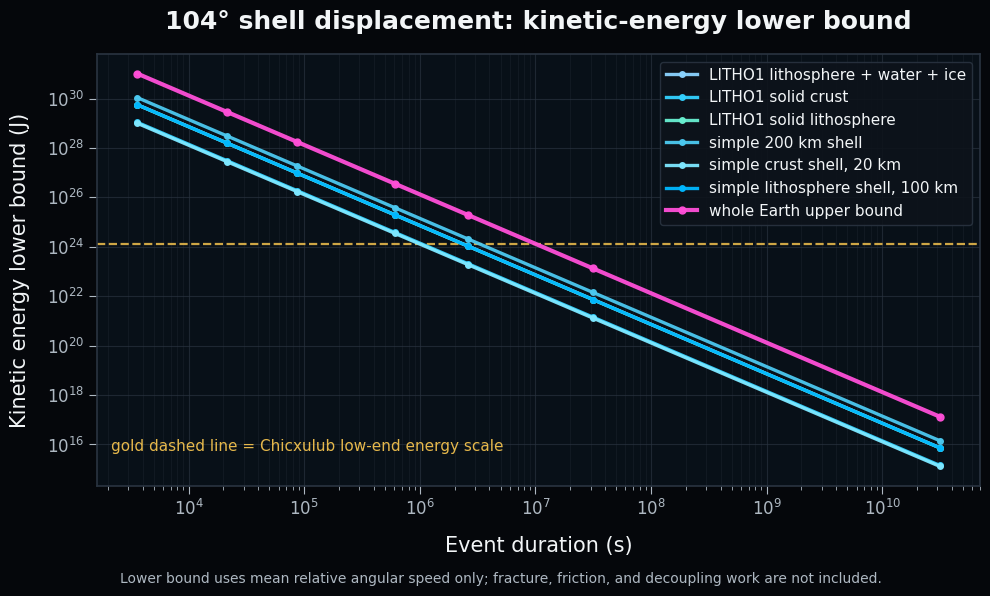

In [11]:
# kinetic energy vs event duration

plot_df = kinematic_energy_df.copy()

# my style
BG = "#05070b"          # near-black
PANEL = "#081018"       # deep navy-black
GRID_MAJOR = "#2a3441"
GRID_MINOR = "#18212b"
TEXT = "#f2f5f7"
SUBTLE = "#aeb8c2"
CYAN_1 = "#7ee7ff"
CYAN_2 = "#33d1ff"
CYAN_3 = "#00b7ff"
CYAN_4 = "#69f0d1"
CYAN_5 = "#8bd3ff"
MAGENTA = "#ff4fd8"
GOLD = "#f2c14e"

series_colors = {
    "simple crust shell, 20 km": CYAN_1,
    "LITHO1 solid crust": CYAN_2,
    "simple lithosphere shell, 100 km": CYAN_3,
    "LITHO1 solid lithosphere": CYAN_4,
    "LITHO1 lithosphere + water + ice": CYAN_5,
    "simple 200 km shell": "#4cc9f0",
    "whole Earth upper bound": MAGENTA,
}

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(PANEL)

# plot each shell case
for shell_name, group in plot_df.groupby("moving_shell"):
    group = group.sort_values("seconds")
    color = series_colors.get(shell_name, CYAN_2)

    lw = 3.0 if shell_name == "whole Earth upper bound" else 2.4
    ms = 5 if shell_name == "whole Earth upper bound" else 4

    ax.plot(
        group["seconds"],
        group["ke_mean_speed_lower_bound_J"],
        marker="o",
        markersize=ms,
        linewidth=lw,
        color=color,
        alpha=0.95,
        label=shell_name,
        zorder=3
    )

# Log scales
ax.set_xscale("log")
ax.set_yscale("log")

# Labels and title
ax.set_title(
    "104° shell displacement: kinetic-energy lower bound",
    fontsize=18,
    color=TEXT,
    weight="bold",
    pad=18
)

ax.set_xlabel("Event duration (s)", fontsize=15, color=TEXT, labelpad=12)
ax.set_ylabel("Kinetic energy lower bound (J)", fontsize=15, color=TEXT, labelpad=12)

# Ticks
ax.tick_params(axis="both", which="major", colors=SUBTLE, labelsize=12, length=6)
ax.tick_params(axis="both", which="minor", colors=SUBTLE, length=3)

# Spines
for spine in ax.spines.values():
    spine.set_color(GRID_MAJOR)
    spine.set_linewidth(1.2)

# Grid
ax.grid(True, which="major", color=GRID_MAJOR, linewidth=0.8, alpha=0.65)
ax.grid(True, which="minor", color=GRID_MINOR, linewidth=0.55, alpha=0.75)

# reference line: Chicxulub low-end energy
ax.axhline(
    E_CHICXULUB_LOW,
    color=GOLD,
    linestyle="--",
    linewidth=1.6,
    alpha=0.85,
    zorder=2
)

ax.text(
    0.015, 0.08,
    "gold dashed line = Chicxulub low-end energy scale",
    transform=ax.transAxes,
    color=GOLD,
    fontsize=11,
    alpha=0.95
)

# Legend
leg = ax.legend(
    loc="upper right",
    fontsize=11,
    frameon=True,
    ncol=1
)
leg.get_frame().set_facecolor("#0d131b")
leg.get_frame().set_edgecolor(GRID_MAJOR)
leg.get_frame().set_alpha(0.88)

for t in leg.get_texts():
    t.set_color(TEXT)

# subtitle / footer note
fig.text(
    0.125, 0.02,
    "Lower bound uses mean relative angular speed only; fracture, friction, and decoupling work are not included.",
    color=SUBTLE,
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [12]:
#test 2 angular impulse + mean torque requirement

rows = []

for _, shell in shell_df.iterrows():
    I = shell["moment_of_inertia_kg_m2"]
    interface_radius = shell["inner_or_interface_radius_m"]

    for label, T in event_windows.items():
        omega_mean = THETA_RAD / T
        omega_peak_triangular = 2 * THETA_RAD / T

        L_mean = I * omega_mean
        L_peak_triangular = I * omega_peak_triangular

        torque_mean = L_mean / T
        torque_triangular_accel = 4 * torque_mean

        basal_shear_mean = uniform_basal_shear_from_torque(torque_mean, interface_radius)
        basal_shear_triangular = uniform_basal_shear_from_torque(torque_triangular_accel, interface_radius)

        rows.append({
            "moving_shell": shell["moving_shell"],
            "timescale": label,
            "seconds": T,
            "angular_impulse_mean_kg_m2_s": L_mean,
            "angular_impulse_peak_start_stop_kg_m2_s": L_peak_triangular,
            "mean_torque_N_m": torque_mean,
            "triangular_accel_torque_N_m": torque_triangular_accel,
            "equivalent_force_each_side_N": force_couple_each_force(torque_mean),
            "basal_shear_for_mean_torque_Pa": basal_shear_mean,
            "basal_shear_for_triangular_torque_Pa": basal_shear_triangular,
            "log10_impulse": log10_safe(L_mean),
            "log10_torque": log10_safe(torque_mean),
            "torque_scale": torque_scale_label(torque_mean),
            "torque_over_tidal": torque_mean / TORQUE_TIDAL_PRESENT,
            "torque_over_EM_core_mantle_est": torque_mean / TORQUE_EM_CORE_MANTLE_EST,
        })

impulse_torque_df = pd.DataFrame(rows)
impulse_torque_df

,moving_shell,timescale,seconds,angular_impulse_mean_kg_m2_s,angular_impulse_peak_start_stop_kg_m2_s,mean_torque_N_m,triangular_accel_torque_N_m,equivalent_force_each_side_N,basal_shear_for_mean_torque_Pa,basal_shear_for_triangular_torque_Pa,log10_impulse,log10_torque,torque_scale,torque_over_tidal,torque_over_EM_core_mantle_est
0,"simple crust shell, 20 km",1 hour,3.600000e+03,3.941898e+32,7.883796e+32,1.094972e+29,4.379887e+29,8.593405e+21,4.330887e+07,1.732355e+08,32.595705,29.039403,extreme / global-coupling torque,2.564401e+12,2.189943e+09
1,"simple crust shell, 20 km",6 hours,2.160000e+04,6.569830e+31,1.313966e+32,3.041588e+27,1.216635e+28,2.387057e+20,1.203024e+06,4.812096e+06,31.817554,27.483100,extreme / global-coupling torque,7.123335e+10,6.083176e+07
2,"simple crust shell, 20 km",1 day,8.640000e+04,1.642458e+31,3.284915e+31,1.900993e+26,7.603970e+26,1.491911e+19,7.518900e+04,3.007560e+05,31.215494,26.278980,huge geophysical torque,4.452084e+09,3.801985e+06
3,"simple crust shell, 20 km",1 week,6.048000e+05,2.346368e+30,4.692736e+30,3.879577e+24,1.551831e+25,3.044716e+17,1.534469e+03,6.137878e+03,30.370396,24.588784,huge geophysical torque,9.085886e+07,7.759153e+04
4,"simple crust shell, 20 km",1 month,2.629800e+06,5.396164e+29,1.079233e+30,2.051930e+23,8.207718e+23,1.610367e+16,8.115894e+01,3.246358e+02,29.732085,23.312162,above EM core-mantle estimate,4.805576e+06,4.103859e+03
5,"simple crust shell, 20 km",1 year,3.155760e+07,4.496804e+28,8.993607e+28,1.424951e+21,5.699804e+21,1.118310e+14,5.636038e-01,2.254415e+00,28.652904,21.153800,above EM core-mantle estimate,3.337205e+04,2.849902e+01
6,"simple crust shell, 20 km","1,000 years",3.155760e+10,4.496804e+25,8.993607e+25,1.424951e+15,5.699804e+15,1.118310e+08,5.636038e-07,2.254415e-06,25.652904,15.153800,below present lunar tidal torque,3.337205e-02,2.849902e-05
7,"simple lithosphere shell, 100 km",1 hour,3.600000e+03,2.225555e+33,4.451109e+33,6.182096e+29,2.472838e+30,4.851747e+22,2.539953e+08,1.015981e+09,33.347438,29.791136,extreme / global-coupling torque,1.447834e+13,1.236419e+10
8,"simple lithosphere shell, 100 km",6 hours,2.160000e+04,3.709258e+32,7.418515e+32,1.717249e+28,6.868996e+28,1.347708e+21,7.055424e+06,2.822170e+07,32.569287,28.234833,extreme / global-coupling torque,4.021761e+11,3.434498e+08
9,"simple lithosphere shell, 100 km",1 day,8.640000e+04,9.273144e+31,1.854629e+32,1.073281e+27,4.293122e+27,8.423172e+19,4.409640e+05,1.763856e+06,31.967227,27.030713,extreme / global-coupling torque,2.513600e+10,2.146561e+07


In [13]:
impulse_torque_df.sort_values(["moving_shell", "seconds"])[
    [
        "moving_shell", "timescale",
        "angular_impulse_mean_kg_m2_s",
        "mean_torque_N_m",
        "basal_shear_for_mean_torque_Pa",
        "log10_impulse", "log10_torque",
        "torque_scale",
        "torque_over_tidal",
        "torque_over_EM_core_mantle_est"
    ]
]

,moving_shell,timescale,angular_impulse_mean_kg_m2_s,mean_torque_N_m,basal_shear_for_mean_torque_Pa,log10_impulse,log10_torque,torque_scale,torque_over_tidal,torque_over_EM_core_mantle_est
35,LITHO1 lithosphere + water + ice,1 hour,2.226650e+33,6.185139e+29,2.548393e+08,33.347652,29.791349,extreme / global-coupling torque,1.448547e+13,1.237028e+10
36,LITHO1 lithosphere + water + ice,6 hours,3.711084e+32,1.718094e+28,7.078870e+06,32.569501,28.235047,extreme / global-coupling torque,4.023740e+11,3.436188e+08
37,LITHO1 lithosphere + water + ice,1 day,9.277709e+31,1.073809e+27,4.424294e+05,31.967441,27.030927,extreme / global-coupling torque,2.514838e+10,2.147618e+07
38,LITHO1 lithosphere + water + ice,1 week,1.325387e+31,2.191447e+25,9.029171e+03,31.122343,25.340731,huge geophysical torque,5.132322e+08,4.382893e+05
39,LITHO1 lithosphere + water + ice,1 month,3.048118e+30,1.159068e+24,4.775578e+02,30.484032,24.064109,huge geophysical torque,2.714514e+07,2.318137e+04
40,LITHO1 lithosphere + water + ice,1 year,2.540098e+29,8.049086e+21,3.316374e+00,29.404851,21.905747,above EM core-mantle estimate,1.885079e+05,1.609817e+02
41,LITHO1 lithosphere + water + ice,"1,000 years",2.540098e+26,8.049086e+15,3.316374e-06,26.404851,15.905747,below present lunar tidal torque,1.885079e-01,1.609817e-04
21,LITHO1 solid crust,1 hour,4.306953e+32,1.196376e+29,4.742233e+07,32.634170,29.077868,extreme / global-coupling torque,2.801887e+12,2.392752e+09
22,LITHO1 solid crust,6 hours,7.178256e+31,3.323267e+27,1.317287e+06,31.856019,27.521565,extreme / global-coupling torque,7.783020e+10,6.646533e+07
23,LITHO1 solid crust,1 day,1.794564e+31,2.077042e+26,8.233044e+04,31.253959,26.317445,huge geophysical torque,4.864388e+09,4.154083e+06


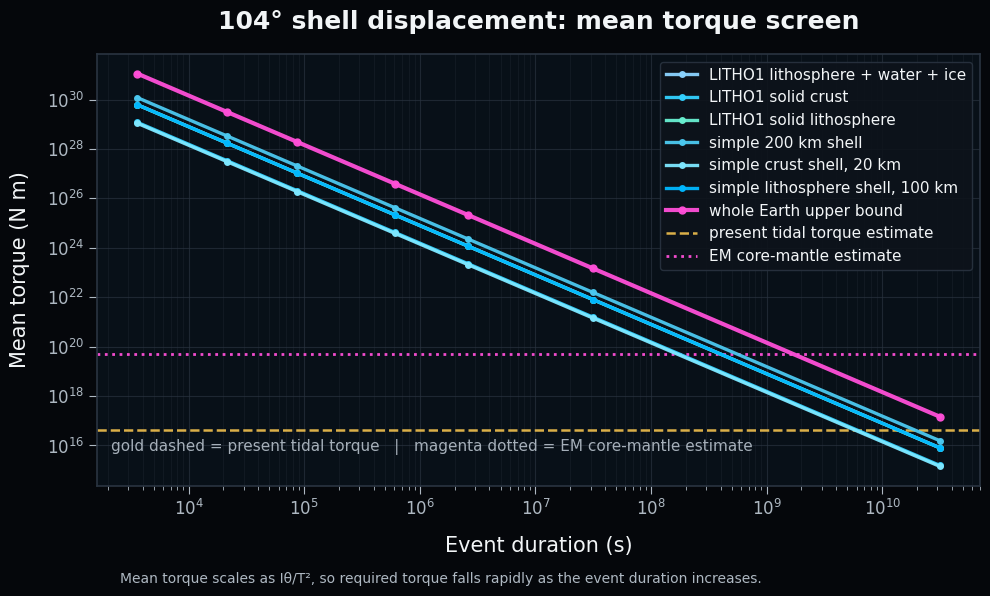

In [14]:
# mean torque vs event duration

plot_df = impulse_torque_df.copy()

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(PANEL)

# plot each shell case
for shell_name, group in plot_df.groupby("moving_shell"):
    group = group.sort_values("seconds")
    color = series_colors.get(shell_name, CYAN_2)

    lw = 3.0 if shell_name == "whole Earth upper bound" else 2.4
    ms = 5 if shell_name == "whole Earth upper bound" else 4

    ax.plot(
        group["seconds"],
        group["mean_torque_N_m"],
        marker="o",
        markersize=ms,
        linewidth=lw,
        color=color,
        alpha=0.95,
        label=shell_name,
        zorder=3
    )

# Reference lines
ax.axhline(
    TORQUE_TIDAL_PRESENT,
    color=GOLD,
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
    label="present tidal torque estimate",
    zorder=2
)

ax.axhline(
    TORQUE_EM_CORE_MANTLE_EST,
    color=MAGENTA,
    linestyle=":",
    linewidth=2.0,
    alpha=0.95,
    label="EM core-mantle estimate",
    zorder=2
)

# Log scales
ax.set_xscale("log")
ax.set_yscale("log")

# Labels and title
ax.set_title(
    "104° shell displacement: mean torque screen",
    fontsize=18,
    color=TEXT,
    weight="bold",
    pad=18
)

ax.set_xlabel("Event duration (s)", fontsize=15, color=TEXT, labelpad=12)
ax.set_ylabel("Mean torque (N m)", fontsize=15, color=TEXT, labelpad=12)

# Ticks
ax.tick_params(axis="both", which="major", colors=SUBTLE, labelsize=12, length=6)
ax.tick_params(axis="both", which="minor", colors=SUBTLE, length=3)

# Spines
for spine in ax.spines.values():
    spine.set_color(GRID_MAJOR)
    spine.set_linewidth(1.2)

# Grid
ax.grid(True, which="major", color=GRID_MAJOR, linewidth=0.8, alpha=0.65)
ax.grid(True, which="minor", color=GRID_MINOR, linewidth=0.55, alpha=0.75)

# Optional annotation
ax.text(
    0.015, 0.08,
    "gold dashed = present tidal torque   |   magenta dotted = EM core-mantle estimate",
    transform=ax.transAxes,
    color=SUBTLE,
    fontsize=11,
    alpha=0.95
)

# Legend
leg = ax.legend(
    loc="upper right",
    fontsize=11,
    frameon=True,
    ncol=1
)
leg.get_frame().set_facecolor("#0d131b")
leg.get_frame().set_edgecolor(GRID_MAJOR)
leg.get_frame().set_alpha(0.88)

for t in leg.get_texts():
    t.set_color(TEXT)

# Footer
fig.text(
    0.125, 0.02,
    "Mean torque scales as Iθ/T², so required torque falls rapidly as the event duration increases.",
    color=SUBTLE,
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

# Compare against physical reservoirs and constraints

This section compares the model outputs against:

- a hypothetical Ben-style solar micronova / solar outburst energy reservoir
- largest-earthquake energy scale
- Chicxulub-scale impact energy range
- Earth's total rotational kinetic energy
- solar energy intercepted by Earth over the same time window
- present lunar tidal torque scale
- estimated electromagnetic core-mantle torque scale
- first-pass basal-shear equivalents

Important: the solar-energy comparison is **not** a claim that solar energy can do this mechanical work. It is only an energy-scale reference. The micronova/outburst case is treated as hypothetical; it is not assumed to be an established solar event class.


In [15]:
# Energy references in joules

solar_outburst_energy_cases = {
    # Mainstream solar flare / superflare-type comparison values
    "large observed solar flare, 10^25 J": 1e25,
    "extreme solar flare / upper flare scale, 10^26 J": 1e26,
    "solar superflare-scale, 10^28 J": 1e28,
    "large solar superflare-scale, 10^30 J": 1e30,

    # Ben-style hypothetical solar micronova screen
    # Astronomical micronovae reported on accreting white dwarfs are around 10^39 erg = 10^32 J.
    # This is not an accepted solar event class; it is included here only as a hypothetical energy screen.
    "hypothetical solar micronova, 10^32 J": 1e32,

    # Extra extreme sensitivity cases
    "extreme hypothetical outburst, 10^34 J": 1e34,
    "extreme hypothetical outburst, 10^36 J": 1e36,
}

coupling_efficiencies = [1.0, 0.1, 0.01, 0.001, 1e-4]

In [16]:
reference_rows = [
    {
        "reference": "largest recorded earthquake, Mw 9.5, rough radiated energy",
        "quantity_type": "energy",
        "value_SI": E_LARGEST_EQ_APPROX,
        "units": "J",
        "log10_value": log10_safe(E_LARGEST_EQ_APPROX),
        "notes": "USGS approximate Mw-energy relation"
    },
    {
        "reference": "Chicxulub low estimate from impactor assessment",
        "quantity_type": "energy",
        "value_SI": E_CHICXULUB_LOW,
        "units": "J",
        "log10_value": log10_safe(E_CHICXULUB_LOW),
        "notes": "broad literature range"
    },
    {
        "reference": "Chicxulub high estimate from impactor assessment",
        "quantity_type": "energy",
        "value_SI": E_CHICXULUB_HIGH,
        "units": "J",
        "log10_value": log10_safe(E_CHICXULUB_HIGH),
        "notes": "broad literature range"
    },
    {
        "reference": "Earth rotational kinetic energy",
        "quantity_type": "energy",
        "value_SI": E_ROT_EARTH,
        "units": "J",
        "log10_value": log10_safe(E_ROT_EARTH),
        "notes": "0.5 I omega^2, I=0.3308MR^2"
    },
    {
        "reference": "Earth rotational angular momentum",
        "quantity_type": "angular momentum",
        "value_SI": L_ROT_EARTH,
        "units": "kg m^2/s",
        "log10_value": log10_safe(L_ROT_EARTH),
        "notes": "I omega"
    },
    {
        "reference": "present lunar tidal torque estimate",
        "quantity_type": "torque",
        "value_SI": TORQUE_TIDAL_PRESENT,
        "units": "N m",
        "log10_value": log10_safe(TORQUE_TIDAL_PRESENT),
        "notes": "derived from 3 TW tidal dissipation / (Omega_Earth - omega_Moon)"
    },
    {
        "reference": "EM core-mantle coupling estimate",
        "quantity_type": "torque",
        "value_SI": TORQUE_EM_CORE_MANTLE_EST,
        "units": "N m",
        "log10_value": log10_safe(TORQUE_EM_CORE_MANTLE_EST),
        "notes": "published order estimate ~5e19 N m"
    },
]

reference_df = pd.DataFrame(reference_rows)
reference_df

,reference,quantity_type,value_SI,units,log10_value,notes
0,"largest recorded earthquake, Mw 9.5, rough rad...",energy,8.317638e+18,J,18.920000,USGS approximate Mw-energy relation
1,Chicxulub low estimate from impactor assessment,energy,1.300000e+24,J,24.113943,broad literature range
2,Chicxulub high estimate from impactor assessment,energy,5.800000e+25,J,25.763428,broad literature range
3,Earth rotational kinetic energy,energy,2.132008e+29,J,29.328789,"0.5 I omega^2, I=0.3308MR^2"
4,Earth rotational angular momentum,angular momentum,5.847441e+33,kg m^2/s,33.766966,I omega
5,present lunar tidal torque estimate,torque,4.269893e+16,N m,16.630417,derived from 3 TW tidal dissipation / (Omega_E...
6,EM core-mantle coupling estimate,torque,5.000000e+19,N m,19.698970,published order estimate ~5e19 N m


In [17]:
# merge  into one summary table
summary_df = (
    kinematic_energy_df
    .merge(
        impulse_torque_df,
        on=["moving_shell", "timescale", "seconds"],
        how="left"
    )
)

summary_df["solar_energy_same_window_J"] = P_SOLAR_INTERCEPTED * summary_df["seconds"]
summary_df["energy_over_largest_eq"] = summary_df["ke_mean_speed_lower_bound_J"] / E_LARGEST_EQ_APPROX
summary_df["energy_over_chicxulub_low"] = summary_df["ke_mean_speed_lower_bound_J"] / E_CHICXULUB_LOW
summary_df["energy_over_earth_rot_ke"] = summary_df["ke_mean_speed_lower_bound_J"] / E_ROT_EARTH
summary_df["energy_over_solar_same_window"] = summary_df["ke_mean_speed_lower_bound_J"] / summary_df["solar_energy_same_window_J"]
summary_df["impulse_over_earth_spin_L"] = summary_df["angular_impulse_mean_kg_m2_s"] / L_ROT_EARTH

final_cols = [
    "moving_shell", "timescale", "seconds",
    "surface_speed_m_s",
    "ke_mean_speed_lower_bound_J",
    "angular_impulse_mean_kg_m2_s",
    "mean_torque_N_m",
    "basal_shear_for_mean_torque_Pa",
    "log10_energy_lower_bound",
    "log10_impulse",
    "log10_torque",
    "energy_scale",
    "torque_scale",
    "energy_over_largest_eq",
    "energy_over_chicxulub_low",
    "energy_over_earth_rot_ke",
    "energy_over_solar_same_window",
    "torque_over_tidal",
    "torque_over_EM_core_mantle_est",
    "impulse_over_earth_spin_L",
]

final_summary_df = summary_df[final_cols].copy()
final_summary_df.sort_values(["moving_shell", "seconds"])

,moving_shell,timescale,seconds,surface_speed_m_s,ke_mean_speed_lower_bound_J,angular_impulse_mean_kg_m2_s,mean_torque_N_m,basal_shear_for_mean_torque_Pa,log10_energy_lower_bound,log10_impulse,log10_torque,energy_scale,torque_scale,energy_over_largest_eq,energy_over_chicxulub_low,energy_over_earth_rot_ke,energy_over_solar_same_window,torque_over_tidal,torque_over_EM_core_mantle_est,impulse_over_earth_spin_L
35,LITHO1 lithosphere + water + ice,1 hour,3.600000e+03,3212.297881,5.613454e+29,2.226650e+33,6.185139e+29,2.548393e+08,29.749230,33.347652,29.791349,exceeds Earth rotational KE,extreme / global-coupling torque,6.748856e+10,4.318042e+05,2.632942e+00,8.984719e+08,1.448547e+13,1.237028e+10,3.807905e-01
36,LITHO1 lithosphere + water + ice,6 hours,2.160000e+04,535.382980,1.559293e+28,3.711084e+32,1.718094e+28,7.078870e+06,28.192928,32.569501,28.235047,planetary rotation-energy scale,extreme / global-coupling torque,1.874682e+09,1.199456e+04,7.313728e-02,4.159592e+06,4.023740e+11,3.436188e+08,6.346508e-02
37,LITHO1 lithosphere + water + ice,1 day,8.640000e+04,133.845745,9.745580e+26,9.277709e+31,1.073809e+27,4.424294e+05,26.988808,31.967441,27.030927,above Chicxulub; below 1% Earth rotation KE,extreme / global-coupling torque,1.171676e+08,7.496600e+02,4.571080e-03,6.499362e+04,2.514838e+10,2.147618e+07,1.586627e-02
38,LITHO1 lithosphere + water + ice,1 week,6.048000e+05,19.120821,1.988894e+25,1.325387e+31,2.191447e+25,9.029171e+03,25.298612,31.122343,25.340731,Chicxulub-range impact scale,huge geophysical torque,2.391176e+06,1.529918e+01,9.328734e-05,1.894858e+02,5.132322e+08,4.382893e+05,2.266610e-03
39,LITHO1 lithosphere + water + ice,1 month,2.629800e+06,4.397396,1.051937e+24,3.048118e+30,1.159068e+24,4.775578e+02,24.021990,30.484032,24.064109,between earthquake and Chicxulub scale,huge geophysical torque,1.264706e+05,8.091823e-01,4.934019e-06,2.304856e+00,2.714514e+07,2.318137e+04,5.212738e-04
40,LITHO1 lithosphere + water + ice,1 year,3.155760e+07,0.366450,7.305118e+21,2.540098e+29,8.049086e+21,3.316374e+00,21.863627,29.404851,21.905747,between earthquake and Chicxulub scale,above EM core-mantle estimate,8.782684e+02,5.619322e-03,3.426402e-08,1.333829e-03,1.885079e+05,1.609817e+02,4.343948e-05
41,LITHO1 lithosphere + water + ice,"1,000 years",3.155760e+10,0.000366,7.305118e+15,2.540098e+26,8.049086e+15,3.316374e-06,15.863627,26.404851,15.905747,below largest-earthquake radiated-energy scale,below present lunar tidal torque,8.782684e-04,5.619322e-09,3.426402e-14,1.333829e-12,1.885079e-01,1.609817e-04,4.343948e-08
21,LITHO1 solid crust,1 hour,3.600000e+03,3212.297881,1.085796e+29,4.306953e+32,1.196376e+29,4.742233e+07,29.035748,32.634170,29.077868,planetary rotation-energy scale,extreme / global-coupling torque,1.305414e+10,8.352280e+04,5.092834e-01,1.737892e+08,2.801887e+12,2.392752e+09,7.365535e-02
22,LITHO1 solid crust,6 hours,2.160000e+04,535.382980,3.016101e+27,7.178256e+31,3.323267e+27,1.317287e+06,27.479446,31.856019,27.521565,planetary rotation-energy scale,extreme / global-coupling torque,3.626151e+08,2.320078e+03,1.414676e-02,8.045794e+05,7.783020e+10,6.646533e+07,1.227589e-02
23,LITHO1 solid crust,1 day,8.640000e+04,133.845745,1.885063e+26,1.794564e+31,2.077042e+26,8.233044e+04,26.275326,31.253959,26.317445,above Chicxulub; below 1% Earth rotation KE,huge geophysical torque,2.266344e+07,1.450049e+02,8.841725e-04,1.257155e+04,4.864388e+09,4.154083e+06,3.068973e-03


In [18]:
# Compare intercepted/coupled solar outburst energy to shell KE

micronova_rows = []

for _, req in final_summary_df.iterrows():
    E_required = req["ke_mean_speed_lower_bound_J"]

    for event_name, E_total in solar_outburst_energy_cases.items():
        E_intercepted = E_total * EARTH_INTERCEPT_FRACTION_ISOTROPIC

        for eta in coupling_efficiencies:
            E_coupled = E_intercepted * eta

            micronova_rows.append({
                "moving_shell": req["moving_shell"],
                "timescale": req["timescale"],
                "required_KE_J": E_required,
                "log10_required_KE": log10_safe(E_required),

                "solar_outburst_case": event_name,
                "solar_outburst_total_energy_J": E_total,
                "log10_solar_outburst_energy": log10_safe(E_total),

                "earth_intercept_fraction": EARTH_INTERCEPT_FRACTION_ISOTROPIC,
                "energy_intercepted_by_earth_J": E_intercepted,
                "log10_energy_intercepted": log10_safe(E_intercepted),

                "coupling_efficiency": eta,
                "energy_coupled_to_shell_J": E_coupled,
                "log10_energy_coupled": log10_safe(E_coupled),

                "coupled_energy_over_required_KE": E_coupled / E_required,
                "passes_energy_only_screen": E_coupled >= E_required,
            })

micronova_energy_screen_df = pd.DataFrame(micronova_rows)

display(micronova_energy_screen_df.head())

,moving_shell,timescale,required_KE_J,log10_required_KE,solar_outburst_case,solar_outburst_total_energy_J,log10_solar_outburst_energy,earth_intercept_fraction,energy_intercepted_by_earth_J,log10_energy_intercepted,coupling_efficiency,energy_coupled_to_shell_J,log10_energy_coupled,coupled_energy_over_required_KE,passes_energy_only_screen
0,"simple crust shell, 20 km",1 hour,9.937648e+28,28.997284,"large observed solar flare, 10^25 J",1.000000e+25,25.0,4.534239e-10,4.534239e+15,15.656504,1.0000,4.534239e+15,15.656504,4.562688e-14,False
1,"simple crust shell, 20 km",1 hour,9.937648e+28,28.997284,"large observed solar flare, 10^25 J",1.000000e+25,25.0,4.534239e-10,4.534239e+15,15.656504,0.1000,4.534239e+14,14.656504,4.562688e-15,False
2,"simple crust shell, 20 km",1 hour,9.937648e+28,28.997284,"large observed solar flare, 10^25 J",1.000000e+25,25.0,4.534239e-10,4.534239e+15,15.656504,0.0100,4.534239e+13,13.656504,4.562688e-16,False
3,"simple crust shell, 20 km",1 hour,9.937648e+28,28.997284,"large observed solar flare, 10^25 J",1.000000e+25,25.0,4.534239e-10,4.534239e+15,15.656504,0.0010,4.534239e+12,12.656504,4.562688e-17,False
4,"simple crust shell, 20 km",1 hour,9.937648e+28,28.997284,"large observed solar flare, 10^25 J",1.000000e+25,25.0,4.534239e-10,4.534239e+15,15.656504,0.0001,4.534239e+11,11.656504,4.562688e-18,False


In [19]:
# Focus on the most relevant displacement windows
micronova_view = micronova_energy_screen_df[
    micronova_energy_screen_df["timescale"].isin(["1 day", "1 week", "1 year", "1,000 years"])
].copy()

# Show only the hypothetical 10^32 J solar micronova case first
micronova_1e32_view = micronova_view[
    micronova_view["solar_outburst_case"] == "hypothetical solar micronova, 10^32 J"
][
    [
        "moving_shell",
        "timescale",
        "required_KE_J",
        "energy_intercepted_by_earth_J",
        "coupling_efficiency",
        "energy_coupled_to_shell_J",
        "coupled_energy_over_required_KE",
        "passes_energy_only_screen",
    ]
].sort_values(
    ["moving_shell", "timescale", "coupling_efficiency"],
    ascending=[True, True, False]
)

display(micronova_1e32_view)

,moving_shell,timescale,required_KE_J,energy_intercepted_by_earth_J,coupling_efficiency,energy_coupled_to_shell_J,coupled_energy_over_required_KE,passes_energy_only_screen
1315,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,4.534239e+22,1.0000,4.534239e+22,4.652610e-05,False
1316,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,4.534239e+22,0.1000,4.534239e+21,4.652610e-06,False
1317,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,4.534239e+22,0.0100,4.534239e+20,4.652610e-07,False
1318,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,4.534239e+22,0.0010,4.534239e+19,4.652610e-08,False
1319,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,4.534239e+22,0.0001,4.534239e+18,4.652610e-09,False
...,...,...,...,...,...,...,...,...
1700,whole Earth upper bound,"1,000 years",1.326467e+17,4.534239e+22,1.0000,4.534239e+22,3.418283e+05,True
1701,whole Earth upper bound,"1,000 years",1.326467e+17,4.534239e+22,0.1000,4.534239e+21,3.418283e+04,True
1702,whole Earth upper bound,"1,000 years",1.326467e+17,4.534239e+22,0.0100,4.534239e+20,3.418283e+03,True
1703,whole Earth upper bound,"1,000 years",1.326467e+17,4.534239e+22,0.0010,4.534239e+19,3.418283e+02,True


In [20]:
# What total isotropic solar outburst energy would be required?

required_outburst_rows = []

for _, req in final_summary_df.iterrows():
    E_required = req["ke_mean_speed_lower_bound_J"]

    for eta in coupling_efficiencies:
        E_total_needed = E_required / (EARTH_INTERCEPT_FRACTION_ISOTROPIC * eta)

        required_outburst_rows.append({
            "moving_shell": req["moving_shell"],
            "timescale": req["timescale"],
            "required_KE_J": E_required,
            "coupling_efficiency": eta,
            "isotropic_solar_outburst_energy_needed_J": E_total_needed,
            "log10_outburst_energy_needed": log10_safe(E_total_needed),
            "relative_to_10^32_J_micronova": E_total_needed / 1e32,
        })

required_solar_outburst_df = pd.DataFrame(required_outburst_rows)

display(
    required_solar_outburst_df[
        required_solar_outburst_df["timescale"].isin(["1 day", "1 week", "1 year", "1,000 years"])
    ].sort_values(["moving_shell", "timescale", "coupling_efficiency"])
)

,moving_shell,timescale,required_KE_J,coupling_efficiency,isotropic_solar_outburst_energy_needed_J,log10_outburst_energy_needed,relative_to_10^32_J_micronova
189,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,0.0001,2.149331e+40,40.332303,2.149331e+08
188,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,0.0010,2.149331e+39,39.332303,2.149331e+07
187,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,0.0100,2.149331e+38,38.332303,2.149331e+06
186,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,0.1000,2.149331e+37,37.332303,2.149331e+05
185,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,1.0000,2.149331e+36,36.332303,2.149331e+04
...,...,...,...,...,...,...,...
244,whole Earth upper bound,"1,000 years",1.326467e+17,0.0001,2.925445e+30,30.466192,2.925445e-02
243,whole Earth upper bound,"1,000 years",1.326467e+17,0.0010,2.925445e+29,29.466192,2.925445e-03
242,whole Earth upper bound,"1,000 years",1.326467e+17,0.0100,2.925445e+28,28.466192,2.925445e-04
241,whole Earth upper bound,"1,000 years",1.326467e+17,0.1000,2.925445e+27,27.466192,2.925445e-05


In [21]:
def micronova_energy_label(ratio):
    if ratio >= 1:
        return "energy sufficient in this idealized screen"
    elif ratio >= 1e-2:
        return "within 2 orders of magnitude"
    elif ratio >= 1e-4:
        return "short by 2–4 orders of magnitude"
    elif ratio >= 1e-6:
        return "short by 4–6 orders of magnitude"
    else:
        return "short by more than 6 orders of magnitude"


micronova_energy_screen_df["energy_screen_label"] = micronova_energy_screen_df[
    "coupled_energy_over_required_KE"
].apply(micronova_energy_label)

In [22]:
requirements = final_summary_df[
    final_summary_df["timescale"].isin(["1 day", "1 week", "1 year", "1,000 years"])
][
    [
        "moving_shell", "timescale",
        "ke_mean_speed_lower_bound_J",
        "angular_impulse_mean_kg_m2_s",
        "mean_torque_N_m",
        "log10_energy_lower_bound",
        "log10_impulse",
        "log10_torque",
        "energy_scale",
    ]
].sort_values(["moving_shell", "timescale"])

requirements

,moving_shell,timescale,ke_mean_speed_lower_bound_J,angular_impulse_mean_kg_m2_s,mean_torque_N_m,log10_energy_lower_bound,log10_impulse,log10_torque,energy_scale
37,LITHO1 lithosphere + water + ice,1 day,9.745580e+26,9.277709e+31,1.073809e+27,26.988808,31.967441,27.030927,above Chicxulub; below 1% Earth rotation KE
38,LITHO1 lithosphere + water + ice,1 week,1.988894e+25,1.325387e+31,2.191447e+25,25.298612,31.122343,25.340731,Chicxulub-range impact scale
40,LITHO1 lithosphere + water + ice,1 year,7.305118e+21,2.540098e+29,8.049086e+21,21.863627,29.404851,21.905747,between earthquake and Chicxulub scale
41,LITHO1 lithosphere + water + ice,"1,000 years",7.305118e+15,2.540098e+26,8.049086e+15,15.863627,26.404851,15.905747,below largest-earthquake radiated-energy scale
23,LITHO1 solid crust,1 day,1.885063e+26,1.794564e+31,2.077042e+26,26.275326,31.253959,26.317445,above Chicxulub; below 1% Earth rotation KE
24,LITHO1 solid crust,1 week,3.847068e+24,2.563663e+30,4.238860e+24,24.585130,30.408861,24.627249,Chicxulub-range impact scale
26,LITHO1 solid crust,1 year,1.413011e+21,4.913248e+28,1.556914e+21,21.150145,28.691369,21.192265,between earthquake and Chicxulub scale
27,LITHO1 solid crust,"1,000 years",1.413011e+15,4.913248e+25,1.556914e+15,15.150145,25.691369,15.192265,below largest-earthquake radiated-energy scale
30,LITHO1 solid lithosphere,1 day,9.662832e+26,9.198933e+31,1.064691e+27,26.985104,31.963737,27.027224,above Chicxulub; below 1% Earth rotation KE
31,LITHO1 solid lithosphere,1 week,1.972007e+25,1.314133e+31,2.172839e+25,25.294908,31.118639,25.337028,Chicxulub-range impact scale


# Reference values used in this notebook

These are order-of-magnitude reference values.

- JPL Solar System Dynamics planetary physical parameters: Earth radius, mass, and rotation values.
- Earth fact sheet values: mean radius, mass, sidereal rotation period, and moment factor `I/(MR²) ≈ 0.3308`.
- USGS: largest recorded earthquake is the 1960 Mw 9.5 Chile earthquake; USGS magnitude-energy relation: `log₁₀(E) = 5.24 + 1.44M`<sub>w</sub>, with energy in joules.
- Durand-Manterola & Cordero-Tercero, Chicxulub impactor assessment: broad kinetic-energy range from `1.3 × 10²⁴ J` to `5.8 × 10²⁵ J`.
- IAU 2015 Resolution B3: nominal total solar irradiance of `1361 W m⁻²`.
- Kuang et al. / NASA ESD summary: electromagnetic core-mantle torque estimate around `5 × 10¹⁹ N m`.
- Lunar tidal torque estimate here is derived from a representative `3 TW` present tidal dissipation and the relative angular speed `(Ω<sub>⊕</sub> − ω<sub>Moon</sub>)`.
- Mantle traction and lithosphere-strength values are broad order-of-magnitude comparisons only; replace with project-specific rheology later.
- Micronova style energies are included only as a hypothetical solar outburst energy screen. 